In [1]:
import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Paths / config
# ------------------------------------------------------------------
DATA_PATH   = "/data/shared/fsibilla/clean_code/Q1/experiments/yem_mvam/full.csv"
RESULTS_DIR = "/data/shared/fsibilla/clean_code/Q1/experiments/yem_mvam/results"
OUTPUT_DIR  = "/data/shared/fsibilla/clean_code/Q1/bayesian/yem_mvam/results"

PSU_LEVEL = 1
SEEDS     = [1, 2, 3, 4, 5]
N_RNVP    = 5

TARGET_COLS = [ "log_exp_pp", "rCSI", "FCS"]
ADM1_COL    = "adm1name"

# ------------------------------------------------------------------
# Load full data in raw units
# ------------------------------------------------------------------
df_full = pd.read_csv(DATA_PATH).copy()

need_cols = TARGET_COLS + [ADM1_COL]
df_full = df_full.dropna(subset=need_cols).copy()

for c in TARGET_COLS:
    df_full[c] = df_full[c].astype(float)

print(df_full.shape)
df_full.head()

(54703, 10)


,id,adm1name,ADM2_NAME,log_exp_pp,rCSI,FCS,wscore_1,entropy_2,adm2geometry,adm1geometry
0,6688817,Ibb,Far' Al Odayn,8.195610,7.0,21.0,-0.061354,0.355058,"POLYGON ((43.77451 14.06848, 43.77696 14.05722...","POLYGON ((43.6548125 13.9143575, 43.6548645 13..."
1,6686152,Ibb,Ar Radmah,8.853665,14.0,33.0,-0.061354,1.171750,POLYGON ((44.44700548800006 14.254293009000037...,"POLYGON ((43.6548125 13.9143575, 43.6548645 13..."
2,6687988,Sana'a,Khawlan,8.172353,21.0,56.0,-0.398529,1.123764,"POLYGON ((44.65487 15.17354, 44.6613 15.15336,...","POLYGON ((43.5080252 15.056638, 43.5192546 15...."
3,6689386,Ibb,Ash Sha'ir,7.957577,12.0,28.0,-0.061354,2.314427,POLYGON ((44.39145139200008 14.077809474000048...,"POLYGON ((43.6548125 13.9143575, 43.6548645 13..."
4,6689572,Ibb,Ash Sha'ir,8.959026,16.0,18.5,-0.061354,2.314427,POLYGON ((44.39145139200008 14.077809474000048...,"POLYGON ((43.6548125 13.9143575, 43.6548645 13..."


In [2]:
true_adm1 = (
    df_full
    .groupby(ADM1_COL)[TARGET_COLS]
    .mean()
    .reset_index()
    .melt(id_vars=ADM1_COL, var_name="variable", value_name="true_mean")
)

true_adm1.head()

,adm1name,variable,true_mean
0,Abyan,log_exp_pp,9.462635
1,Ad Dali',log_exp_pp,9.380311
2,Aden,log_exp_pp,9.537773
3,Al Bayda,log_exp_pp,8.963754
4,Al Hodeidah,log_exp_pp,8.908576


In [3]:
def aggregate_bayes_to_adm1(mu_df, std_df, adm1_series, target_cols, adm1_col="adm1name"):
    """
    mu_df:  dataframe with columns mu_<target>
    std_df: dataframe with columns std_<target>
    adm1_series: ADM1 labels aligned row-by-row with mu_df/std_df
    """
    work = pd.DataFrame({adm1_col: adm1_series.values})

    # ADM1 mean of posterior means
    for c in target_cols:
        work[f"mu_{c}"] = mu_df[f"mu_{c}"].values
        work[f"std_{c}"] = std_df[f"std_{c}"].values

    grouped = work.groupby(adm1_col, dropna=False)

    mean_part = grouped[[f"mu_{c}" for c in target_cols]].mean().reset_index()

    # std of the ADM1 average under independence:
    # sqrt(sum_i sigma_i^2) / n
    std_records = []
    for adm1, g in grouped:
        n = len(g)
        row = {adm1_col: adm1}
        for c in target_cols:
            s = g[f"std_{c}"].to_numpy(dtype=float)
            row[f"bayes_std_{c}"] = np.sqrt(np.sum(s**2)) / n
        std_records.append(row)

    std_part = pd.DataFrame(std_records)

    out = mean_part.merge(std_part, on=adm1_col, how="left")

    rename_mu = {f"mu_{c}": f"bayes_mean_{c}" for c in target_cols}
    out = out.rename(columns=rename_mu)

    return out

In [4]:
all_seed_results = []

for seed in SEEDS:
    print(f"Processing seed {seed}")

    out_seed_dir = os.path.join(OUTPUT_DIR, f"seed_{seed}")

    # --------------------------------------------------------------
    # 1) RealNVP: ADM1 means for each run, then mean/std across runs
    # --------------------------------------------------------------
    run_tables = []

    for run_idx in range(N_RNVP):
        run_path = os.path.join(out_seed_dir, f"rnvp_generated_run{run_idx}.csv")
        df_run = pd.read_csv(run_path)

        # IMPORTANT:
        # generated rows are in the same order as df_full / C_full used in generation
        # so we attach ADM1 from df_full by row alignment
        df_run[ADM1_COL] = df_full[ADM1_COL].values

        run_adm1 = (
            df_run
            .groupby(ADM1_COL)[TARGET_COLS]
            .mean()
            .reset_index()
        )
        run_adm1["run_idx"] = run_idx
        run_tables.append(run_adm1)

    rnvp_adm1_allruns = pd.concat(run_tables, ignore_index=True)

    gen_summary = (
        rnvp_adm1_allruns
        .groupby(ADM1_COL)[TARGET_COLS]
        .agg(["mean", "std"])
        .reset_index()
    )

    # flatten MultiIndex columns
    gen_summary.columns = [
        ADM1_COL if col[0] == ADM1_COL else f"gen_{col[1]}_{col[0]}"
        for col in gen_summary.columns
    ]

    # --------------------------------------------------------------
    # 2) Bayesian: aggregate row-level mu/std to ADM1
    # --------------------------------------------------------------
    mu_path  = os.path.join(out_seed_dir, "bayes_mu.csv")
    std_path = os.path.join(out_seed_dir, "bayes_std.csv")

    mu_df  = pd.read_csv(mu_path)
    std_df = pd.read_csv(std_path)

    bayes_adm1 = aggregate_bayes_to_adm1(
        mu_df=mu_df,
        std_df=std_df,
        adm1_series=df_full[ADM1_COL],
        target_cols=TARGET_COLS,
        adm1_col=ADM1_COL
    )

    # --------------------------------------------------------------
    # 3) Merge true + generated + bayesian, then reshape long
    # --------------------------------------------------------------
    merged_wide = true_adm1.pivot(index=ADM1_COL, columns="variable", values="true_mean").reset_index()

    # merge generated
    merged_wide = merged_wide.merge(gen_summary, on=ADM1_COL, how="left")

    # merge bayesian
    merged_wide = merged_wide.merge(bayes_adm1, on=ADM1_COL, how="left")

    # build long table variable by variable
    rows = []
    for _, r in merged_wide.iterrows():
        adm1 = r[ADM1_COL]
        for var in TARGET_COLS:
            rows.append({
                "seed": seed,
                "adm1": adm1,
                "variable": var,
                "true_mean": r[var],
                "gen_mean": r[f"gen_mean_{var}"],
                "gen_std": r[f"gen_std_{var}"],
                "bayes_mean": r[f"bayes_mean_{var}"],
                "bayes_std": r[f"bayes_std_{var}"],
            })

    seed_result = pd.DataFrame(rows)
    all_seed_results.append(seed_result)

comparison_adm1 = pd.concat(all_seed_results, ignore_index=True)

comparison_adm1.head()

Processing seed 1
Processing seed 2
Processing seed 3
Processing seed 4
Processing seed 5


,seed,adm1,variable,true_mean,gen_mean,gen_std,bayes_mean,bayes_std
0,1,Abyan,log_exp_pp,9.462635,9.440360,0.015204,9.457605,0.020678
1,1,Abyan,rCSI,14.476738,16.497789,0.827506,15.827648,0.354777
2,1,Abyan,FCS,35.135194,34.209593,0.842729,34.030260,0.355655
3,1,Ad Dali',log_exp_pp,9.380311,8.984200,0.041763,9.025176,0.021673
4,1,Ad Dali',rCSI,17.758495,18.116546,0.604320,17.902363,0.371838


In [5]:
print(comparison_adm1.shape)
print(comparison_adm1.isna().sum())

comparison_adm1.groupby("seed")["adm1"].nunique()

(330, 8)
seed          0
adm1          0
variable      0
true_mean     0
gen_mean      0
gen_std       0
bayes_mean    0
bayes_std     0
dtype: int64


seed
1    22
2    22
3    22
4    22
5    22
Name: adm1, dtype: int64

## Average and plot

In [6]:
import numpy as np
import pandas as pd

def aggregate_over_seeds(df, mean_col, std_col, group_cols):
    """
    Combine seed-level means and stds into one mean and one propagated std.
    
    Total variance of the averaged estimate:
        mean( sigma_s^2 ) / S   ? no, for average of independent estimates:
        sum(sigma_s^2) / S^2
    plus between-seed variance of means:
        var(mu_s, ddof=1) / S
    """
    records = []

    for keys, g in df.groupby(group_cols, dropna=False):
        mus = g[mean_col].to_numpy(dtype=float)
        sigmas = g[std_col].to_numpy(dtype=float)
        S = len(g)

        mean_avg = np.mean(mus)

        # propagated within-seed uncertainty of the averaged estimate
        within_var = np.sum(sigmas**2) / (S**2)

        # between-seed uncertainty of the averaged estimate
        if S > 1:
            between_var = np.var(mus, ddof=1) / S
        else:
            between_var = 0.0

        total_std = np.sqrt(within_var + between_var)

        row = {}
        if isinstance(keys, tuple):
            for col, val in zip(group_cols, keys):
                row[col] = val
        else:
            row[group_cols[0]] = keys

        row[f"{mean_col}_avg"] = mean_avg
        row[f"{std_col}_prop"] = total_std
        row[f"{mean_col}_between_seed_sd"] = np.std(mus, ddof=1) if S > 1 else 0.0
        row["n_seeds"] = S
        records.append(row)

    return pd.DataFrame(records)


# true value is the same across seeds, so just take first (or mean, same result)
true_avg = (
    comparison_adm1
    .groupby(["adm1", "variable"], as_index=False)
    .agg(true_mean=("true_mean", "mean"))
)

gen_avg = aggregate_over_seeds(
    comparison_adm1,
    mean_col="gen_mean",
    std_col="gen_std",
    group_cols=["adm1", "variable"]
)

bayes_avg = aggregate_over_seeds(
    comparison_adm1,
    mean_col="bayes_mean",
    std_col="bayes_std",
    group_cols=["adm1", "variable"]
)

plot_avg = (
    true_avg
    .merge(gen_avg, on=["adm1", "variable"], how="left")
    .merge(bayes_avg, on=["adm1", "variable"], how="left", suffixes=("", "_bayes"))
)

display(plot_avg.head())

,adm1,variable,true_mean,gen_mean_avg,gen_std_prop,gen_mean_between_seed_sd,n_seeds,bayes_mean_avg,bayes_std_prop,bayes_mean_between_seed_sd,n_seeds_bayes
0,Abyan,FCS,35.135194,36.557701,2.099347,4.625093,5,36.244993,1.561908,3.470642,5
1,Abyan,log_exp_pp,9.462635,9.425474,0.027823,0.050904,5,9.394544,0.020490,0.040297,5
2,Abyan,rCSI,14.476738,14.341022,1.595183,3.416639,5,14.678325,1.197356,2.655627,5
3,Ad Dali',FCS,32.591930,36.876570,0.722741,1.544898,5,37.088078,0.448275,0.914806,5
4,Ad Dali',log_exp_pp,9.380311,9.084989,0.058704,0.126773,5,9.074938,0.031372,0.066313,5


In [7]:
plot_avg = plot_avg.rename(columns={
    "gen_mean_avg": "gen_mean",
    "gen_std_prop": "gen_std",
    "bayes_mean_avg": "bayes_mean",
    "bayes_std_prop": "bayes_std",
})

plot_avg.head()

,adm1,variable,true_mean,gen_mean,gen_std,gen_mean_between_seed_sd,n_seeds,bayes_mean,bayes_std,bayes_mean_between_seed_sd,n_seeds_bayes
0,Abyan,FCS,35.135194,36.557701,2.099347,4.625093,5,36.244993,1.561908,3.470642,5
1,Abyan,log_exp_pp,9.462635,9.425474,0.027823,0.050904,5,9.394544,0.020490,0.040297,5
2,Abyan,rCSI,14.476738,14.341022,1.595183,3.416639,5,14.678325,1.197356,2.655627,5
3,Ad Dali',FCS,32.591930,36.876570,0.722741,1.544898,5,37.088078,0.448275,0.914806,5
4,Ad Dali',log_exp_pp,9.380311,9.084989,0.058704,0.126773,5,9.074938,0.031372,0.066313,5


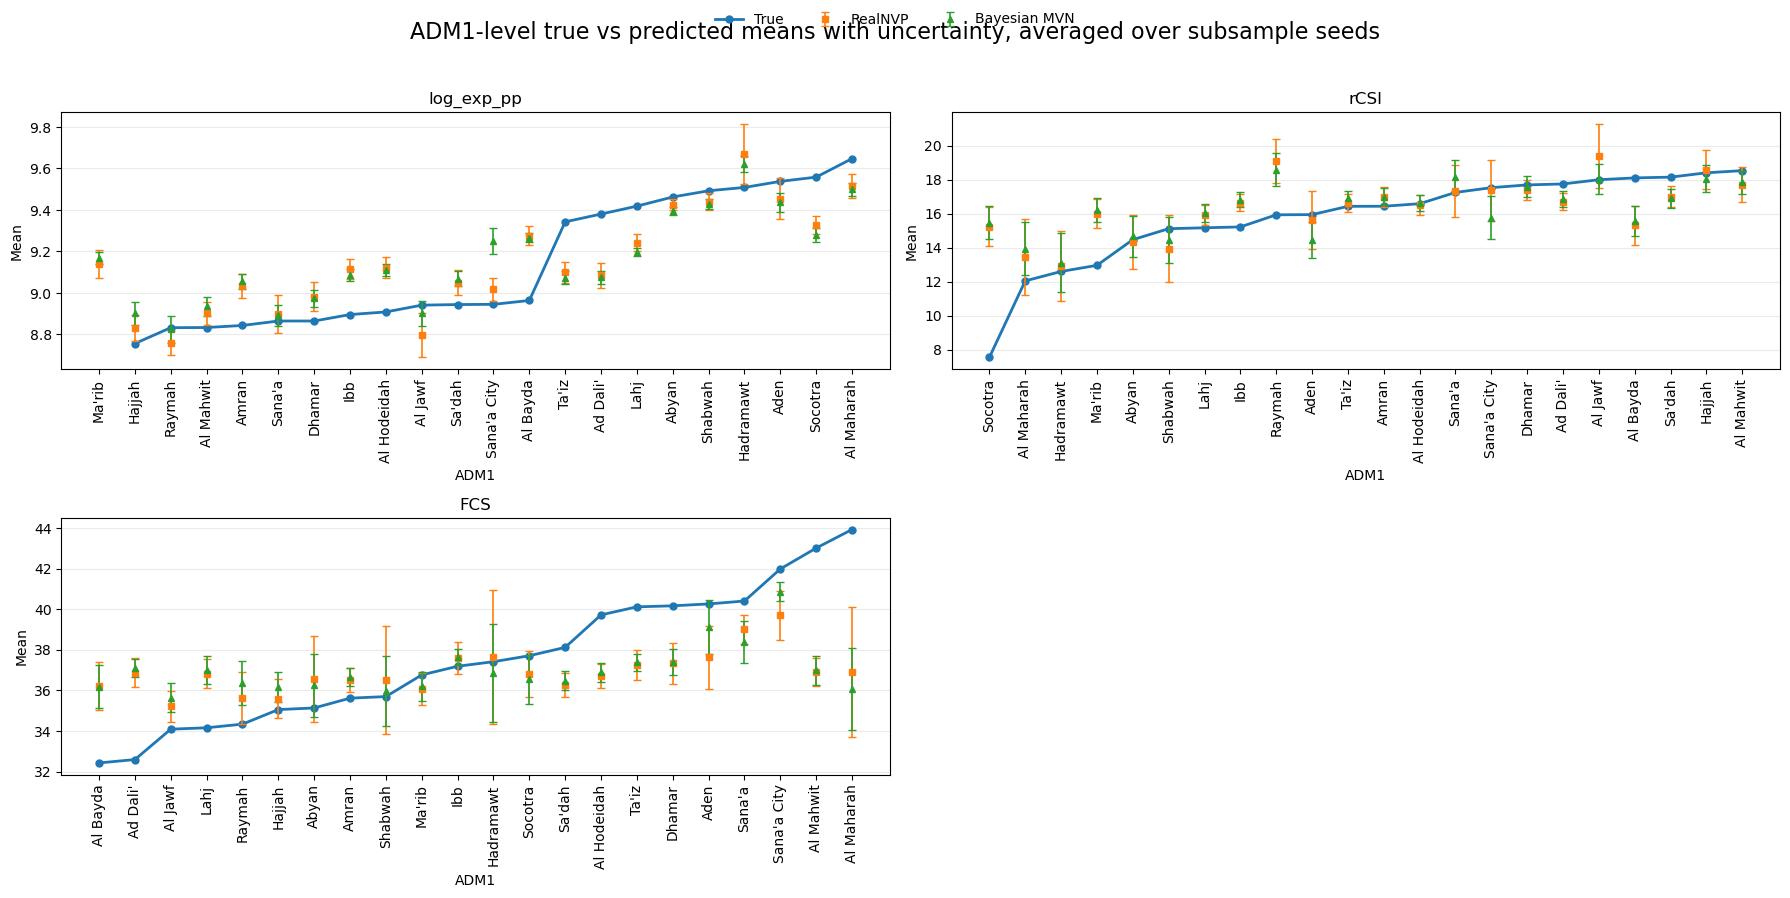

In [8]:
import matplotlib.pyplot as plt
import numpy as np

variables = TARGET_COLS
n_vars = len(variables)

ncols = 2
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows), sharex=False)
axes = np.array(axes).reshape(-1)

for ax, var in zip(axes, variables):
    sub = plot_avg.loc[plot_avg["variable"] == var].copy()

    # sort ADM1 by true value for readability
    sub = sub.sort_values("true_mean").reset_index(drop=True)
    x = np.arange(len(sub))

    # True
    ax.plot(
        x,
        sub["true_mean"],
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=5,
        label="True"
    )

    # RealNVP averaged over seeds with propagated uncertainty
    ax.errorbar(
        x,
        sub["gen_mean"],
        yerr=sub["gen_std"],
        fmt="s",
        capsize=3,
        elinewidth=1.2,
        markersize=5,
        label="RealNVP"
    )

    # Bayesian averaged over seeds with propagated uncertainty
    ax.errorbar(
        x,
        sub["bayes_mean"],
        yerr=sub["bayes_std"],
        fmt="^",
        capsize=3,
        elinewidth=1.2,
        markersize=5,
        label="Bayesian MVN"
    )

    ax.set_title(var, fontsize=12)
    ax.set_xlabel("ADM1")
    ax.set_ylabel("Mean")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["adm1"], rotation=90)
    ax.grid(axis="y", alpha=0.25)

for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

fig.suptitle("ADM1-level true vs predicted means with uncertainty, averaged over subsample seeds", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [9]:
plot_avg["gen_abs_err"] = np.abs(plot_avg["gen_mean"] - plot_avg["true_mean"])
plot_avg["bayes_abs_err"] = np.abs(plot_avg["bayes_mean"] - plot_avg["true_mean"])

plot_avg["gen_sq_err"] = (plot_avg["gen_mean"] - plot_avg["true_mean"]) ** 2
plot_avg["bayes_sq_err"] = (plot_avg["bayes_mean"] - plot_avg["true_mean"]) ** 2

plot_avg["delta_abs_err"] = plot_avg["gen_abs_err"] - plot_avg["bayes_abs_err"]
plot_avg["winner_abs"] = np.where(
    plot_avg["delta_abs_err"] < 0,
    "RealNVP",
    np.where(plot_avg["delta_abs_err"] > 0, "Bayesian MVN", "Tie")
)

plot_avg.head()

,adm1,variable,true_mean,gen_mean,gen_std,gen_mean_between_seed_sd,n_seeds,bayes_mean,bayes_std,bayes_mean_between_seed_sd,n_seeds_bayes,gen_abs_err,bayes_abs_err,gen_sq_err,bayes_sq_err,delta_abs_err,winner_abs
0,Abyan,FCS,35.135194,36.557701,2.099347,4.625093,5,36.244993,1.561908,3.470642,5,1.422507,1.109798,2.023525,1.231652,0.312708,Bayesian MVN
1,Abyan,log_exp_pp,9.462635,9.425474,0.027823,0.050904,5,9.394544,0.020490,0.040297,5,0.037161,0.068091,0.001381,0.004636,-0.030930,RealNVP
2,Abyan,rCSI,14.476738,14.341022,1.595183,3.416639,5,14.678325,1.197356,2.655627,5,0.135716,0.201587,0.018419,0.040637,-0.065871,RealNVP
3,Ad Dali',FCS,32.591930,36.876570,0.722741,1.544898,5,37.088078,0.448275,0.914806,5,4.284640,4.496149,18.358143,20.215354,-0.211508,RealNVP
4,Ad Dali',log_exp_pp,9.380311,9.084989,0.058704,0.126773,5,9.074938,0.031372,0.066313,5,0.295322,0.305373,0.087215,0.093252,-0.010051,RealNVP


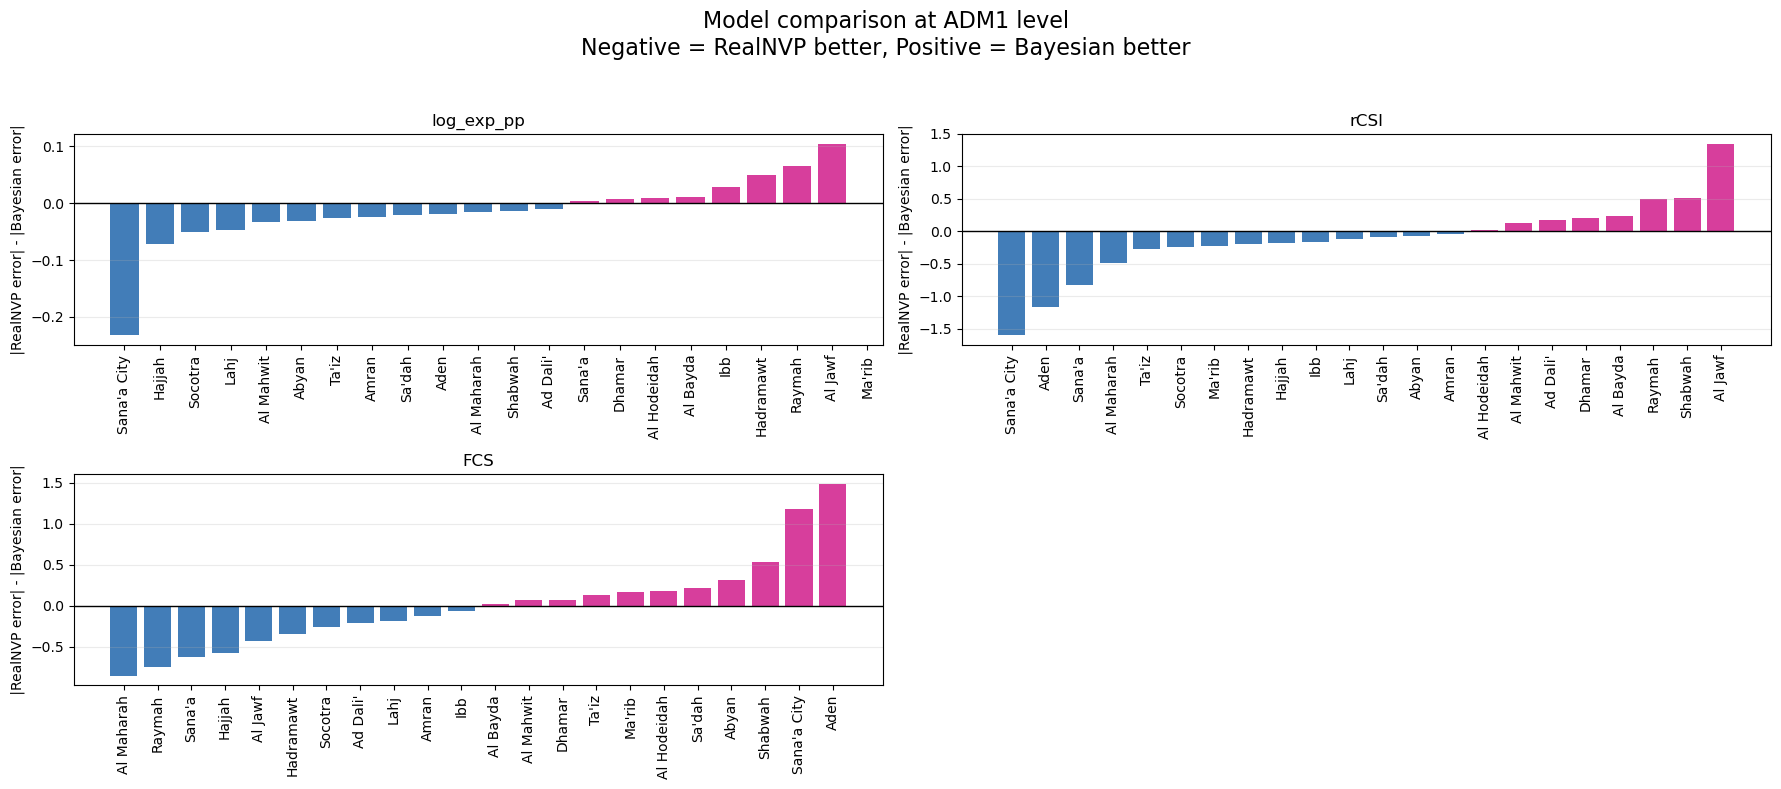

In [10]:
import matplotlib.pyplot as plt
import numpy as np

variables = TARGET_COLS
n_vars = len(variables)

ncols = 2
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=False)
axes = np.array(axes).reshape(-1)

for ax, var in zip(axes, variables):
    sub = plot_avg.loc[plot_avg["variable"] == var].copy()
    sub = sub.sort_values("delta_abs_err").reset_index(drop=True)

    x = np.arange(len(sub))
    colors = np.where(sub["delta_abs_err"] < 0, "#2166ac", "#d01c8b")

    ax.axhline(0, color="black", linewidth=1)
    ax.bar(x, sub["delta_abs_err"], color=colors, alpha=0.85)

    ax.set_title(var)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["adm1"], rotation=90)
    ax.set_ylabel(" |RealNVP error| - |Bayesian error| ")
    ax.grid(axis="y", alpha=0.25)

for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Model comparison at ADM1 level\nNegative = RealNVP better, Positive = Bayesian better", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [11]:
plot_avg.to_csv(os.path.join('/data/shared/fsibilla/clean_code/Q1/bayesian/yem_mvam', "eval_adm1.csv"), index=False)